# DQN CartPole Practice

## 실습 목표

이번 실습에서는 강화학습의 기본 환경인 CartPole을 사용하여 DQN을 구현한다.

CartPole은 카트를 왼쪽 또는 오른쪽으로 움직여 막대가 넘어지지 않도록 오래 버티는 문제이다.

이번 실습을 통해 state, action, reward, environment, agent의 의미를 이해하고, Q-value를 신경망으로 근사하는 DQN의 기본 흐름을 실습한다.

## 강화학습 핵심 용어

- Agent: 행동을 선택하는 주체
- Environment: 에이전트가 상호작용하는 환경
- State: 현재 환경 상태
- Action: 에이전트가 선택하는 행동
- Reward: 행동 결과로 받는 보상
- Done: 에피소드 종료 여부
- Q-value: 특정 상태에서 특정 행동을 했을 때 기대되는 가치
- DQN: Q-value를 신경망으로 근사하는 강화학습 알고리즘

## 세부 실습 구성

### 실습 1. CartPole 환경 이해

CartPole 환경을 생성하고, state, action, reward, done의 의미를 확인한다.

- 환경 생성
- 상태 공간 확인
- 행동 공간 확인
- 랜덤 행동 실행

### 실습 2. DQN 모델 구현

CartPole의 상태값을 입력받아 각 행동의 Q-value를 출력하는 신경망을 구현한다.

- 입력층: state 차원
- 은닉층: Linear + ReLU
- 출력층: action 개수만큼 Q-value 출력

### 실습 3. Replay Buffer와 행동 선택

에이전트가 경험한 transition을 저장하고, epsilon-greedy 방식으로 탐험과 활용을 조절한다.

- state, action, reward, next_state, done 저장
- 랜덤 샘플링으로 미니배치 구성
- epsilon 값에 따라 랜덤 행동 또는 Q-value 기반 행동 선택

### 실습 4. DQN 학습 및 결과 확인

미니배치를 이용해 Q-value를 학습하고, 에피소드별 누적 보상이 증가하는지 확인한다.

- 현재 Q-value 계산
- target Q-value 계산
- 손실 함수 계산
- 역전파와 optimizer 업데이트
- 누적 보상 그래프 시각화

카트를 왼쪽 또는 오른쪽으로 움직여서
막대가 넘어지지 않도록 오래 버티는 문제

### 실습 1. CartPole 환경 이해

CartPole 환경을 생성하고, state, action, reward, done의 의미를 확인한다.

- 환경 생성
- 상태 공간 확인
- 행동 공간 확인
- 랜덤 행동 실행

In [29]:
# 라이브러리 불러오기
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

In [30]:
# device 설정
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("사용 device:", device)

사용 device: mps


device 설정 이유 복습

1. GPU/MPS가 있으면 더 빠르게 계산하기 위해서
2. 모델과 데이터를 같은 장치에 올려 오류를 방지하기 위해서
3. 나중에 코드에서 .to(device)를 일관되게 쓰기 위해서

In [31]:
# CartPole 환경 생성
#Gymnasium : 강화학습 환경들을 모아둔 파이썬 라이브러리, CartPole-v1 : Gymnasium 안에 들어 있는 대표적인 강화학습 연습용 환경
env = gym.make("CartPole-v1")

# 환경을 처음 상태로 초기화
state, info = env.reset(seed=42)

# 처음 상태값 4개 출력
print("초기 state:", state)

#상태가 몇 개의 숫자로 구성되어있는지 확인
print("state shape:", state.shape)

# 환경이 추가로 제공하는 정보 확인
print("info:", info)

초기 state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
state shape: (4,)
info: {}


In [32]:
# 상태 공간과 행동 공간 확인
# 강화학습에서 state는 에이전트가 현재 환경을 보고 판단하는 정보
# CartPole의 행동은 2개
print("상태 공간:", env.observation_space)
print("행동 공간:", env.action_space)

print("상태 차원:", env.observation_space.shape[0])
print("행동 개수:", env.action_space.n)

상태 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
행동 공간: Discrete(2)
상태 차원: 4
행동 개수: 2


DQN은 상태 4개를 입력받아서 행동 2개 각각의 Q-value를 출력하게 된다.

입력: state 4개

출력: Q(left), Q(right)

In [33]:
# 랜덤 행동으로 환경 한 번 실행하기
# 왼쪽 혹은 오른쪽으로 이동하는 행동 중 무작위로 하나 선택
action = env.action_space.sample()

# 선택한 행동을 환경에 적용
# env.step(action)은 강화학습에서 가장 중요한 함수 중 하나(강화학습에서 에이전트가 환경과 상호작용하는 핵심 단계)
#현재 상태에서 action을 실행한다. 그 결과로 다음 상태, 보상, 종료 여부를 받는다.
next_state, reward, terminated, truncated, info = env.step(action)

print("선택한 action:", action)
print("다음 state:", next_state)
print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
print("info:", info)

선택한 action: 1
다음 state: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
reward: 1.0
terminated: False
truncated: False
info: {}


next_state
→ 행동 후 바뀐 다음 상태

reward
→ 행동 결과로 받은 보상 (CartPole에서는 막대가 넘어지지 않고 버티면 보통 매 step마다 보상 1.0을 받는다.)

terminated
→ 실패 또는 성공 조건으로 에피소드가 끝났는지, 막대가 너무 기울거나 카트가 범위를 벗어나서 에피소드가 끝났는지 확인. (True일 경우 실패 조건 때문에 종료)

truncated
→ 시간 제한 때문에 에피소드가 끝났는지(오래 버티면 최대 step 제한에 도달할 수 있습니다. 이때 truncated=True가 된다.)

info
→ 환경이 제공하는 추가 정보

### 실습 2. DQN 모델 구현

CartPole의 상태값을 입력받아 각 행동의 Q-value를 출력하는 신경망을 구현한다.

- 입력층: state 차원
- 은닉층: Linear + ReLU
- 출력층: action 개수만큼 Q-value 출력

In [34]:
# DQN 모델 정의
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        #부모 클래스인 nn.Module의 초기 설정 실행
        super().__init__()
        #신경망 층을 순서대로 쌓기위한 단계
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    # 모델에 입력 x가 들어왔을 때 어떻게 계산할지 정의하는 함수
    def forward(self, x):
        return self.net(x)

#CartPole의 상태차원
state_dim = env.observation_space.shape[0]
#CartPole의 행동 계수
action_dim = env.action_space.n

#DQN 모델을 실제로 생성하고 장치로 보내기
policy_net = DQN(state_dim, action_dim).to(device)

print(policy_net)

DQN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


나중에 어떤 상태가 들어오면 모델은 어느쪽으로 가는 게 좋아보이는 정도인 Q-value를 말해줌

Q-value= 어떤 state에서 어떤 action을 선택했을 때 기대되는 미래 보상의 총합

예를 들어 DQN이 상태를 입력받아 다음과 같이 출력했다면

[12.5, 18.3]

에이전트는 보통 Q-value가 높은 오른쪽 행동을 선택할 것.

In [35]:
# 현재 state를 DQN에 넣어 Q-value 확인하기
# 현재 상태를 파이토치 텐서로 변환. state의 원래 형태는 넘파이.
state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)

#학습이 아닌 Q-value 확인이기 때문에 기울기 계산 끔.
with torch.no_grad():
    #현재 state를 DQN 모델에 넣기 -> Q-Value 출력
    q_values = policy_net(state_tensor)

#모델에 들어가는 state 텐서 모양 확인
print("state_tensor shape:", state_tensor.shape)

# Q-value들 확인
print("Q-values:", q_values)
print("왼쪽 행동 Q-value:", q_values[0, 0].item())
print("오른쪽 행동 Q-value:", q_values[0, 1].item())

# Q-value가 더 큰 행동의 위치 선택
selected_action = q_values.argmax(dim=1).item()
print("Q-value가 가장 큰 행동:", selected_action)

state_tensor shape: torch.Size([1, 4])
Q-values: tensor([[-0.0660, -0.0638]], device='mps:0')
왼쪽 행동 Q-value: -0.06598387658596039
오른쪽 행동 Q-value: -0.063751220703125
Q-value가 가장 큰 행동: 1


DQN이 현재 state에서 더 좋다고 판단한 행동을 출력한다.

다만 지금은 학습 전이기 때문에 이 선택은 아직 믿을 만한 선택은 아님.
다음 단계부터는 경험을 쌓고, Replay Buffer를 만들고, DQN을 학습시키면서 이 Q-value를 점점 의미 있게 바꿔간다.

### 실습 3. Replay Buffer와 행동 선택

에이전트가 경험한 transition을 저장하고, epsilon-greedy 방식으로 탐험과 활용을 조절한다.

- state, action, reward, next_state, done 저장
- 랜덤 샘플링으로 미니배치 구성
- epsilon 값에 따라 랜덤 행동 또는 Q-value 기반 행동 선택

In [36]:
# Replay Buffer 구현
from collections import deque

#DQN에서는 에이전트가 환경과 상호작용하면서 얻은 경험을 바로 한 번만 쓰지 않고, 저장해두었따가 나중에 무작위로 꺼내서 학습한다
class ReplayBuffer:
    #capacity는 버퍼에 최대 몇 개의 경험을 저장할지 정하는 값
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    #새로운 경험을 버퍼에 저장하는 함수
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    #버퍼에서 경험을 무작위로 꺼내는 함수
    def sample(self, batch_size):
        #버퍼 안에 있는 경험 중 batch_size개를 무작위로 뽑음
        batch = random.sample(self.buffer, batch_size)
        #뽑은 경험들을 종류별로 분리
        states, actions, rewards, next_states, dones = zip(*batch)

        #파이토치 텐서로 바꾸고 장치로 보내기
        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        #done=True는 1.0, done=False는 0.0
        dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

        #미니배치 학습에 사용할 값들을 반환
        return states, actions, rewards, next_states, dones

    #버퍼에 저장된 경험 개수 반환
    def __len__(self):
        return len(self.buffer)

#버퍼 클래스 사용. 최대 10000개의 경험을 저장할 수 있는 버퍼를 만들기
replay_buffer = ReplayBuffer(capacity=10000)

print("Replay Buffer 생성 완료")
#처음 만들었으니 0개
print("현재 저장된 경험 개수:", len(replay_buffer))

Replay Buffer 생성 완료
현재 저장된 경험 개수: 0


Replay Buffer는 에이전트가 환경에서 얻은 경험을 저장하는 공간이다.

DQN은 이 경험들을 무작위로 다시 꺼내서 학습한다.

이렇게 하면 최근 경험에만 치우치지 않고 더 안정적으로 학습할 수 있다.

In [37]:
# epsilon-greedy 행동 선택 함수
# 행동을 선택하는 함수 만들기
def select_action(state, epsilon):
    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = policy_net(state_tensor)
        action = q_values.argmax(dim=1).item()

    return action


epsilon = 1.0
action = select_action(state, epsilon)

print("epsilon:", epsilon)
print("선택된 action:", action)

epsilon: 1.0
선택된 action: 0


epsilon-greedy는 탐험과 활용을 조절하는 방법이다.

epsilon 확률
→ 랜덤 행동으로 탐험

1 - epsilon 확률
→ DQN이 계산한 Q-value가 가장 큰 행동 선택

학습 초반에는 모델이 아직 뭘 모르는 상태라 epsilon을 크게 두고 많이 탐험한다.
학습이 진행될수록 epsilon을 줄여서 점점 모델이 좋다고 판단한 행동을 더 많이 선택하게 한다.

#처음에는 많이 탐험하고, 나중에는 배운 대로 행동하게 만드는 장치

다음 단계는 select_action()으로 행동을 고르고, 그 행동을 환경에 적용한 뒤, 얻은 경험을 Replay Buffer에 저장하는 과정

In [38]:
# 선택한 행동으로 경험을 만들고 Replay Buffer에 저장하기
# 환경을 초기 상태로 리셋(새로운 상태를 시작)
state, info = env.reset(seed=42)

# 탐험확률을 1.0으로 설정
epsilon = 1.0
# 현재 state를 보고 행동을 하나 선택(1.0이므로 랜덤 행동 선택)
action = select_action(state, epsilon)

# 선택한 행동을 실제 환경에 적용
next_state, reward, terminated, truncated, info = env.step(action)
# 에피소드가 끝났는지
done = terminated or truncated

# 방금 얻은 경험을 Replay에 저장
# 저장되는 형태는 (state, action, reward, next_state, done), 이것을 transition
replay_buffer.push(state, action, reward, next_state, done)

print("state:", state)
print("action:", action)
print("reward:", reward)
print("next_state:", next_state)
print("done:", done)
print("현재 Replay Buffer 크기:", len(replay_buffer))

state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
action: 1
reward: 1.0
next_state: [ 0.02727336  0.18847767  0.03625453 -0.26141977]
done: False
현재 Replay Buffer 크기: 1


이 과정이 DQN 학습 데이터가 쌓이는 과정

이제 여러 경험을 Replay Buffer에 쌓는 단계

DQN은 경험 1개만으로 학습하지 않고, 여러 경험을 저장한 뒤 그 중 일부를 랜덤하게 뽑아서 학습

In [39]:
# 여러 경험을 Replay Buffer에 쌓기(200번)
# 초기 상태로 리셋
state, info = env.reset(seed=42)

# 경험 200번을 Replay Buffer에 쌓기
for step in range(200):
    # 가능한 행동 중 하나를 랜덤 선택
    action = env.action_space.sample()
    # 선택 행동을 환경에 적용
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    #현재 경험을 저장
    replay_buffer.push(state, action, reward, next_state, done)

    # 다음 반복을 위해 현재 상태를 방금 받은 next_state로 바꾸기
    state = next_state

    # 만약 막대가 쓰러졌거나 시간 제한으로 에피소드가 끝났다면 환경을 다시 초기화
    if done:
        state, info = env.reset()

# 저장된 경험 수 확인
print("현재 Replay Buffer 크기:", len(replay_buffer))

현재 Replay Buffer 크기: 201


환경과 상호작용
→ 경험 저장
→ Replay Buffer에 누적
→ 랜덤하게 미니배치 추출
→ DQN 학습

DQN 학습 흐름
1. 현재 state를 DQN에 넣는다.
2. DQN이 action별 Q-value를 출력한다.
3. 실제 선택한 action의 Q-value를 뽑는다.
4. reward와 next_state를 이용해 목표 Q-value를 만든다.
5. 현재 Q-value와 목표 Q-value의 차이를 손실로 계산한다.
6. loss.backward()로 기울기를 계산한다.
7. optimizer.step()으로 DQN의 가중치를 업데이트한다.

즉 DQN이 예측한 값 vs 실제로 경험해보니 맞춰야 할 값. 이 둘의 차이를 줄이는 방향으로 신경망 학습

이 단계까지는 아직 본격적인 신경망 학습은 시작 전이고 학습을 위한 준비 단계이다.

### 실습 4. DQN 학습 및 결과 확인

미니배치를 이용해 Q-value를 학습하고, 에피소드별 누적 보상이 증가하는지 확인한다.

- 현재 Q-value 계산
- target Q-value 계산
- 손실 함수 계산
- 역전파와 optimizer 업데이트
- 누적 보상 그래프 시각화

In [40]:
# DQN을 학습시키기 전 필요한 설정들을 준비
# 두번쨰 DQN 모델 만들기
# 앞에 만들었던 policy_net DQN 모델은 계쏙 학습되는 현재 DQN이고 이것은 목표 Q-value 계산에 사용하는 고정된 DQN
# 학습을 안정적으로 만들기 위해 모델 두 개 사용
target_net = DQN(state_dim, action_dim).to(device)
# 기존 가중치를 그대로 복사(시작할 떄는 두 모델이 같은 상태)
target_net.load_state_dict(policy_net.state_dict())
# 학습 모드 켜기
target_net.eval()

# 손실 함수 설정(MSELoss → 예측값과 목표값의 차이를 제곱해서 평균낸 손실 함수)
criterion = nn.MSELoss()

# 가중치를 업데이트 할 옵티마이저 만들기
optimizer = optim.Adam(policy_net.parameters(), lr=0.001)

# 할인율, 미래 보상을 어마나 중요하게 볼지 정하는 값. 1에 가까울수록 미래 보상을 중요하게 봄
gamma = 0.99

#Replay Buffer에서 한번에 경험 64개를 뽑아 학습
batch_size = 64

# epsilon greedy에 사용할 값
epsilon = 1.0
epsilon_min = 0.01
# 시간이 지날수록 epsilon 줄임
epsilon_decay = 0.995

print("target_net 생성 완료")
print("손실 함수:", criterion)
print("optimizer:", optimizer)
print("gamma:", gamma)
print("batch_size:", batch_size)
print("epsilon:", epsilon)

target_net 생성 완료
손실 함수: MSELoss()
optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
gamma: 0.99
batch_size: 64
epsilon: 1.0


In [41]:
# Replay Buffer에서 미니배치를 뽑아 DQN 한 번 학습하기 단계
# DQN 한 번 학습하는 함수
def train_step():
    if len(replay_buffer) < batch_size:
        return None

    # 랜덤하게 뽑은 64개의 경험을 종류별로 나누기
    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    # 현재 state들을 policy_net(학습시킬 DQN)에 넣어서 행동별 Q-value 계산
    current_q_values = policy_net(states).gather(1, actions)

    # 정답으로 쓸 target Q-value는 기울기 계산을 하지 않음
    with torch.no_grad():
        # 다음 상태 next_state를 target_net 에 넣기 -> 다음 상태에서 가능한 행동들의 Q-value가 나온다(그중 큰 값)
        next_q_values = target_net(next_states).max(dim=1, keepdim=True)[0]
        # DQN이 맞춰야 할 목표 Q-value
        # target Q-value = 지금 받은 보상 + 미래에 받을 것으로 기대되는 보상
        target_q_values = rewards + gamma * next_q_values * (1 - dones)

    # 현재 DQN이 예측한 Q-value와 목표 Q-value의 차이를 손실로 계산
    loss = criterion(current_q_values, target_q_values)

    # 이전 학습에서 남아 있던 기울기를 초기화
    optimizer.zero_grad()
    # 손실을 기준으로 역전파를 수행. 즉 DQN의 가중치를 어느 방향으로 바꿔야 손실이 줄어드는지 계산
    loss.backward()
    # 계산된 기울기를 이용해 policy_net의 가중치를 업데이트(실제 학습하는 단계)
    optimizer.step()

    # 학습 손실값을 숫자로 반환
    return loss.item()


loss = train_step()
print("loss:", loss)

loss: 1.051593542098999


loss: 값

= Replay Buffer에서 뽑은 경험 64개에 대해,

DQN이 예측한 Q-value와 목표 Q-value 사이의 평균제곱오차가 이 값이라는 뜻

이제 하나씩 하나씩 하는게 아닌 여러 에피소드 동안 DQN 학습하기 실습

In [42]:
# 여러 에피소드 동안 DQN 학습하기
# 200번의 에피소드. 에피소드 하나는 CartPole이 시작해서 막대가 쓰러지거나 제한 시간에 도달할 때까지의 한 판
num_episodes = 200
# 10 에피소드마다 policy_net의 가중치를 target_net에 복사
target_update = 10
# 각 에피소드의 누적보상과 학습 손실 저장 리스트
episode_rewards = []
losses = []

# 200번의 에피소드 학습
for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False

    while not done:
        # 현재 state에서 행동 선택
        action = select_action(state, epsilon)

        #선택한 행동을 환경에 적용하고 결과 받아서 replay_buffer에 저장
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        #replay buffer는 에피소드안에서 버틴 스텝수만큼 추가
        replay_buffer.push(state, action, reward, next_state, done)

        # Replay Buffer에서 미니배치를 뽑아 DQN을 한 번 학습. 실제 policy_net의 가중치가 업데이트
        loss = train_step()

        # 학습이 이루어졌다면 손실값 저장
        if loss is not None:
            losses.append(loss)

        # 다음 반복에서는 방금 받은 next_state가 현재 state가 됨
        state = next_state
        #보상 누적(오래 버틸수록 매 스텝마다 보상 1을 받기에 클수록 오래 버틴 것)
        total_reward += reward

    # 에피소드가 끝나면 그 에피소드의 총 보상 저장
    episode_rewards.append(total_reward)
    # 에피소드가 끝날때마다 epsilon을 줄임
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # 10 에피소드마다 policy_net의 최신 가중치를 target_net에 복사(target Q-value 계산 기준을 주기적으로 갱신)
    if (episode + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    # 10 에피소드마다 학습 상태를 출력
    if (episode + 1) % 10 == 0:
        # 최근 10개 에피소드의 평균 보상을 계산
        recent_avg_reward = np.mean(episode_rewards[-10:])
        print(
            f"Episode {episode + 1}, "
            f"Average Reward: {recent_avg_reward:.2f}, "
            f"Epsilon: {epsilon:.4f}"
        )

Episode 10, Average Reward: 17.60, Epsilon: 0.9511
Episode 20, Average Reward: 21.20, Epsilon: 0.9046
Episode 30, Average Reward: 17.10, Epsilon: 0.8604
Episode 40, Average Reward: 25.80, Epsilon: 0.8183
Episode 50, Average Reward: 40.50, Epsilon: 0.7783
Episode 60, Average Reward: 25.20, Epsilon: 0.7403
Episode 70, Average Reward: 37.90, Epsilon: 0.7041
Episode 80, Average Reward: 28.90, Epsilon: 0.6696
Episode 90, Average Reward: 40.10, Epsilon: 0.6369
Episode 100, Average Reward: 41.30, Epsilon: 0.6058
Episode 110, Average Reward: 86.40, Epsilon: 0.5762
Episode 120, Average Reward: 106.40, Epsilon: 0.5480
Episode 130, Average Reward: 86.80, Epsilon: 0.5212
Episode 140, Average Reward: 94.70, Epsilon: 0.4957
Episode 150, Average Reward: 78.60, Epsilon: 0.4715
Episode 160, Average Reward: 68.60, Epsilon: 0.4484
Episode 170, Average Reward: 39.00, Epsilon: 0.4265
Episode 180, Average Reward: 70.80, Epsilon: 0.4057
Episode 190, Average Reward: 50.50, Epsilon: 0.3858
Episode 200, Average

학습은 어느 정도 되고 있음
초반보다 평균 보상이 올라감
하지만 아직 안정적이지는 않음
epsilon이 아직 높아서 랜덤 행동이 많이 남아 있음

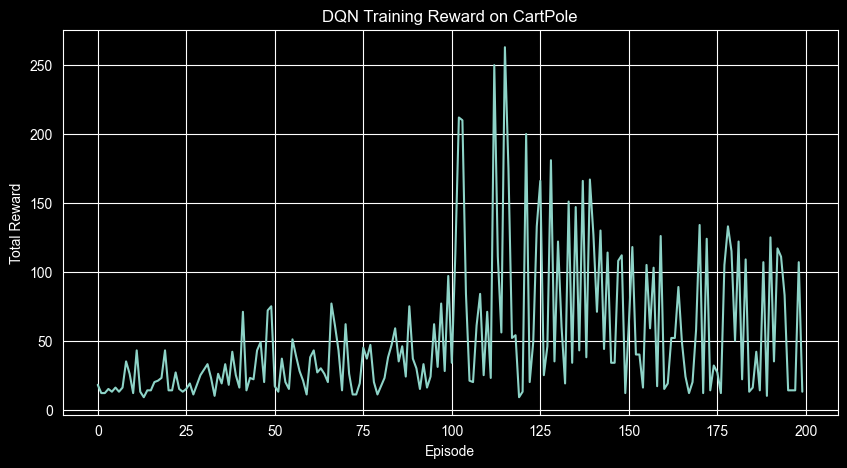

In [43]:
# 에피소드별 누적 보상 시각화
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Training Reward on CartPole")
plt.show()

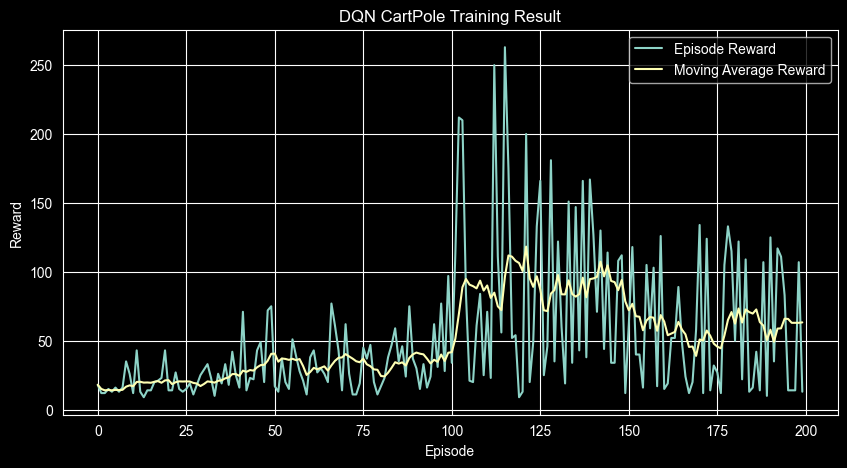

In [44]:
# 최근 10개 에피소드 평균 보상 계산
moving_avg = []

for i in range(len(episode_rewards)):
    recent_rewards = episode_rewards[max(0, i-9):i+1]
    moving_avg.append(np.mean(recent_rewards))

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, label="Episode Reward")
plt.plot(moving_avg, label="Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN CartPole Training Result")
plt.legend()
plt.show()